# Explainability and Experiment Tracking

Uses SHAP to explain the best XGBoost model on the test set, and logs the main model variants to MLflow.

In [2]:
import pandas as pd
import numpy as np
import shap
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import xgboost as xgb
from sklearn.metrics import (average_precision_score, recall_score,
                              precision_score, f1_score, matthews_corrcoef,
                              confusion_matrix,roc_auc_score)

In [3]:
mlflow.set_experiment("Credit_Fraud_Detection")

# Load data
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
X_test  = pd.read_csv("../data/X_test.csv")
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

print(f"X_train: {X_train_f.shape}")
print(f"X_test:  {X_test_f.shape}")


X_train: (226980, 27)
X_test:  (56746, 27)


In [4]:
# Train best model
scale_pos = (y_train==0).sum() / (y_train==1).sum()

best_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    verbosity=0
)
best_model.fit(X_train_f, y_train)
print("Best model trained")

Best model trained


Building a SHAP explainer for the trained model.

In [5]:
# SHAP Analysis
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_f)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value: {explainer.expected_value:.4f}")

Calculating SHAP values...
SHAP values shape: (56746, 27)
Base value: -0.0457


SHAP summary plot, overall feature importance and how each feature pushes predictions toward fraud or legitimate.

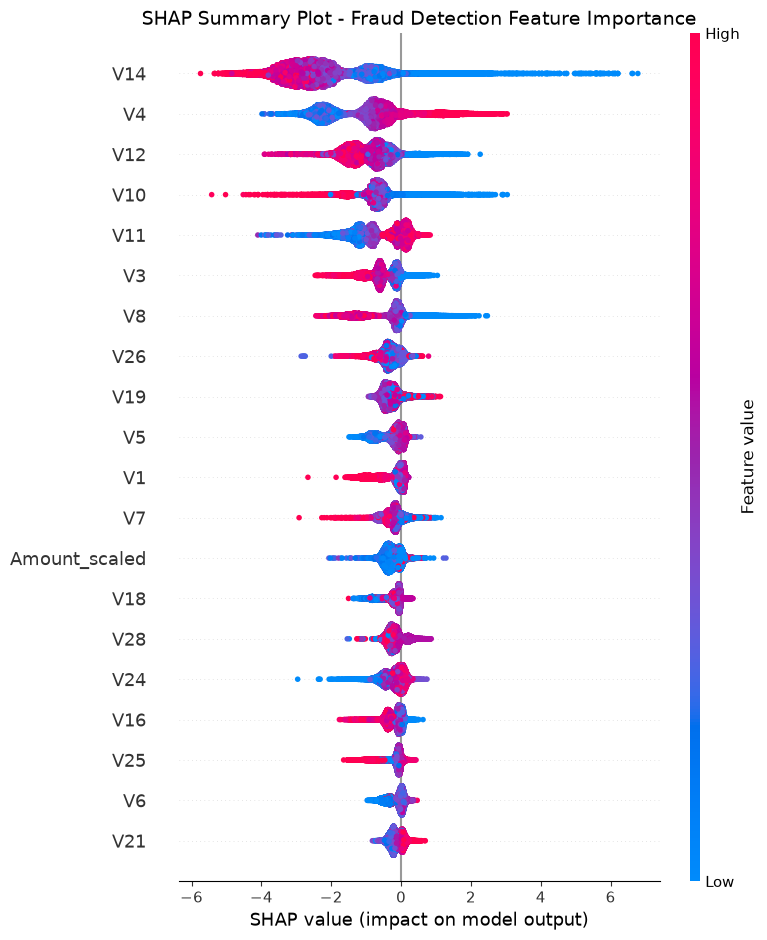

In [6]:
# Summary Plot - global feature importance
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_test_f,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Fraud Detection Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('../results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


Waterfall plot for a single fraud case, showing which features drove that specific prediction.

100%|===================| 56663/56746 [05:04<00:00]        

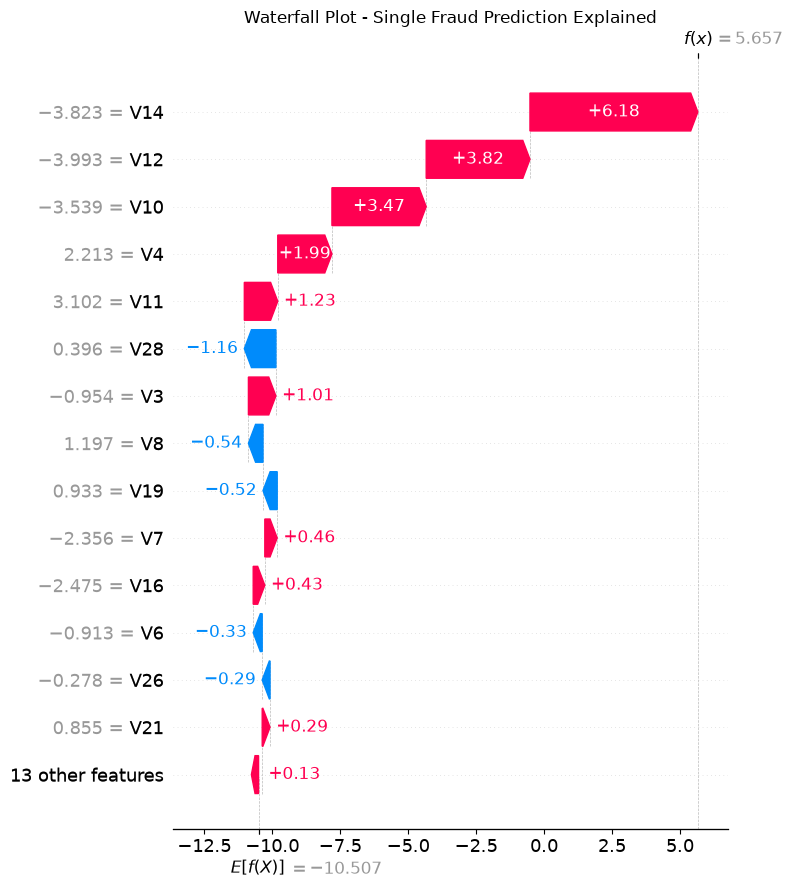

Fraud probability for this transaction: 0.9965
Actual label: FRAUD 


In [7]:
# Waterfall plot - explain one fraud case
fraud_indices = y_test[y_test==1].index.tolist()
most_confident_fraud = fraud_indices[0]

# Get position in X_test
pos = X_test.index.tolist().index(most_confident_fraud)

explainer_v2 = shap.Explainer(best_model, X_test_f)
shap_explanation = explainer_v2(X_test_f)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(
    shap_explanation[pos],
    max_display=15,
    show=False
)
plt.title('Waterfall Plot - Single Fraud Prediction Explained')
plt.tight_layout()
plt.savefig('../results/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

y_prob = best_model.predict_proba(X_test_f)[:, 1]
fraud_prob = y_prob[pos]
print(f"Fraud probability for this transaction: {fraud_prob:.4f}")
print(f"Actual label: FRAUD " if y_test.iloc[pos]==1 else "Actual: LEGITIMATE")

Dependence plots for the top 3 features by SHAP importance.

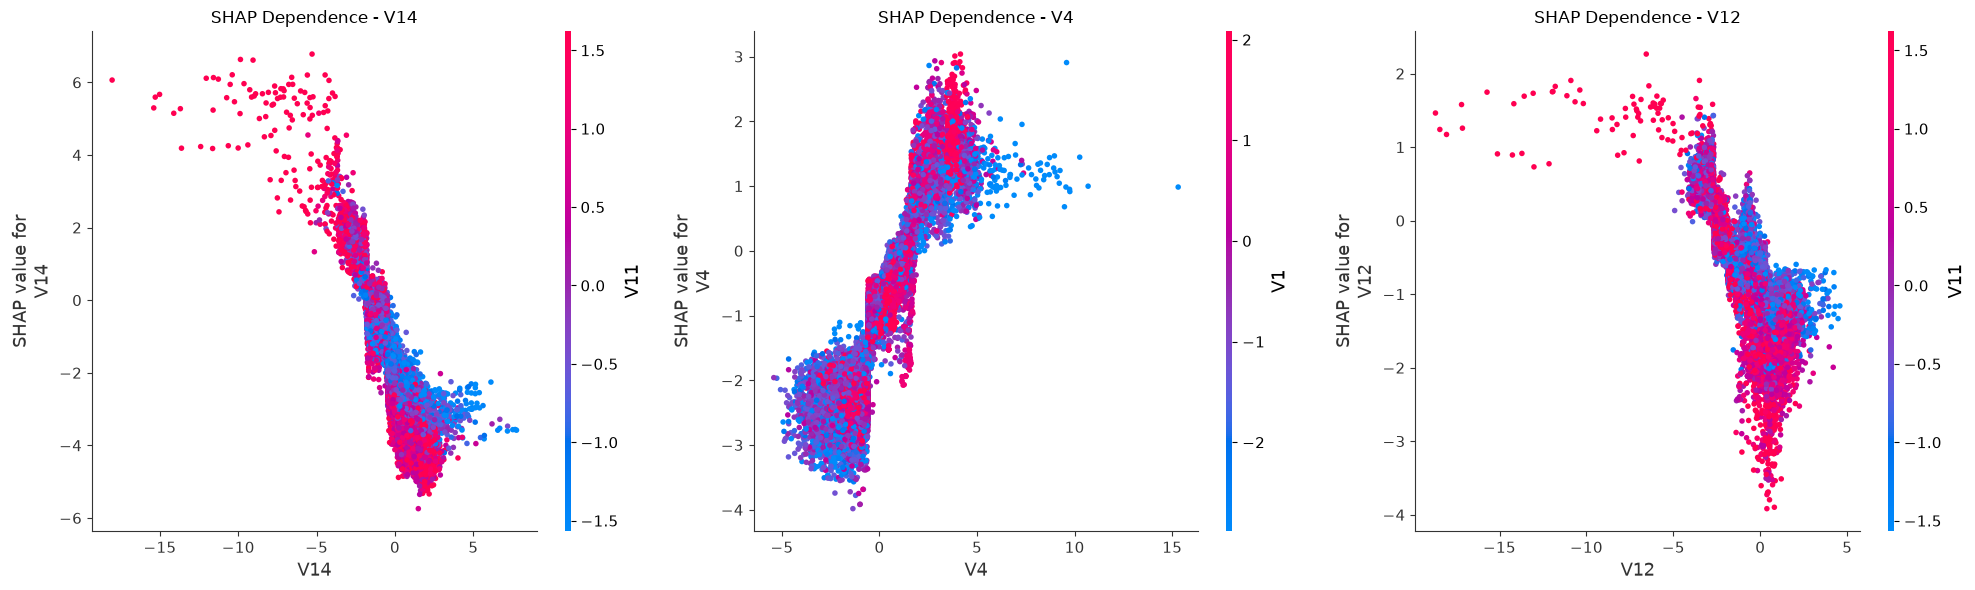

In [8]:
# Dependence plots - top 3 features
top_features = pd.DataFrame({
    'feature': X_test_f.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_f,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence - {feature}')

plt.tight_layout()
plt.savefig('../results/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Comparing SHAP importance against XGBoost's built in feature importance.

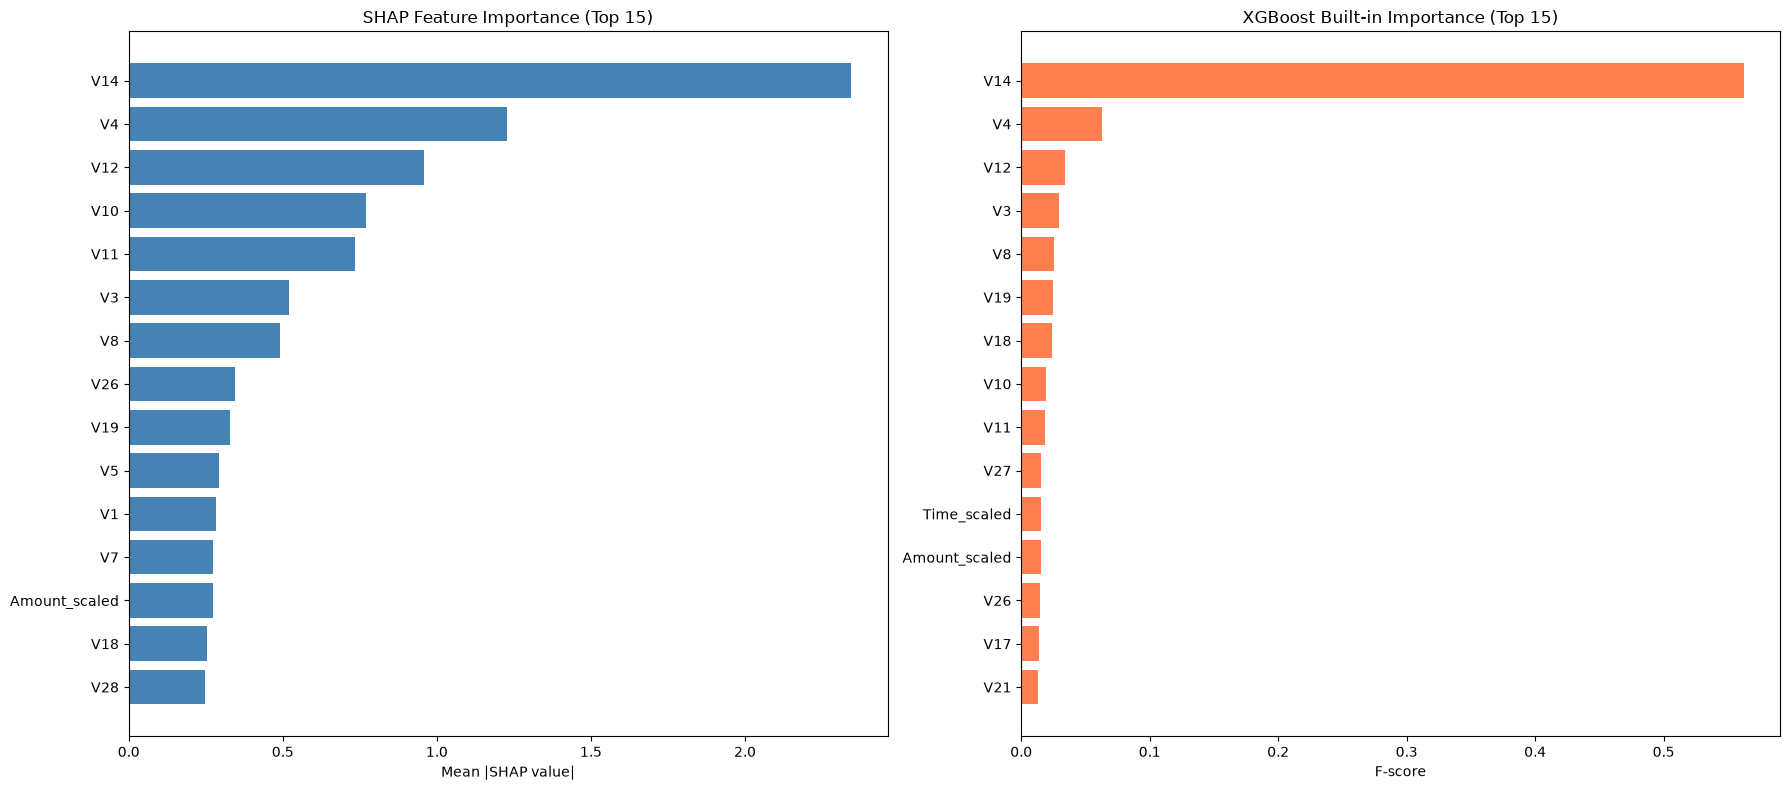

Top 5 SHAP features:
feature  shap_importance
    V14         2.345128
     V4         1.227705
    V12         0.958465
    V10         0.768901
    V11         0.735512


In [9]:
# Feature importance comparison
shap_importance = pd.DataFrame({
    'feature': X_test_f.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False).head(15)

xgb_importance = pd.DataFrame({
    'feature': X_test_f.columns,
    'xgb_importance': best_model.feature_importances_
}).sort_values('xgb_importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(shap_importance['feature'][::-1],
             shap_importance['shap_importance'][::-1],
             color='steelblue')
axes[0].set_title('SHAP Feature Importance (Top 15)')
axes[0].set_xlabel('Mean |SHAP value|')

axes[1].barh(xgb_importance['feature'][::-1],
             xgb_importance['xgb_importance'][::-1],
             color='coral')
axes[1].set_title('XGBoost Built-in Importance (Top 15)')
axes[1].set_xlabel('F-score')

plt.tight_layout()
plt.savefig('../results/feature_importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 SHAP features:")
print(shap_importance.head(5).to_string(index=False))

Logging the main model variants to MLflow for tracking.

In [10]:
print("Logging all experiments to MLflow...")

experiments = {
    'XGB_Original': {
        'model': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=6, scale_pos_weight=scale_pos,
            random_state=42, n_jobs=-1, verbosity=0),
        'X_train': X_train_f,
        'y_train': y_train
    },
    'XGB_SMOTE': {
        'model': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=6, random_state=42,
            n_jobs=-1, verbosity=0),
        'X_train': pd.read_csv('../data/X_train_smote.csv').astype(float),
        'y_train': pd.read_csv('../data/y_train_smote.csv').squeeze()
    },
    'XGB_SMOTETomek': {
        'model': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=6, random_state=42,
            n_jobs=-1, verbosity=0),
        'X_train': pd.read_csv('../data/X_train_combined.csv').astype(float),
        'y_train': pd.read_csv('../data/y_train_combined.csv').squeeze()
    }
}

for exp_name, config in experiments.items():
    with mlflow.start_run(run_name=exp_name):
        model = config['model']
        model.fit(config['X_train'], config['y_train'])

        y_pred = model.predict(X_test_f)
        y_prob = model.predict_proba(X_test_f)[:, 1]

        mlflow.log_params(model.get_params())
        mlflow.log_metrics({
            'recall':    recall_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred),
            'auc_pr':    average_precision_score(y_test, y_prob),
            'auc_roc':   roc_auc_score(y_test, y_prob),
            'mcc':       matthews_corrcoef(y_test, y_pred)
        })

        print(f" {exp_name} logged")



Logging all experiments to MLflow...
 XGB_Original logged
 XGB_SMOTE logged
 XGB_SMOTETomek logged


In [11]:
print(shap_importance.head(5).to_string(index=False))
print(f"Fraud probability: {fraud_prob:.4f}")
print(f"Actual label: {y_test.iloc[pos]}")

feature  shap_importance
    V14         2.345128
     V4         1.227705
    V12         0.958465
    V10         0.768901
    V11         0.735512
Fraud probability: 0.9965
Actual label: 1
